## Imports

In [1]:
from keras import layers, optimizers, Input, Model, callbacks, regularizers, metrics
from methods.load_data import load_ucsf
from methods.visualisation import plot_training_history, plot_binary_segmentation_prediction

IMAGE_SIZE = 128

## Get dataset

In [2]:
x_train, y_train, x_val, y_val, x_test, y_test = load_ucsf(debug=False, classification=False, basic_mask=True, image_size=IMAGE_SIZE)
print(f"Training shape: x_train - {x_train.shape}, y_train - {y_train.shape}")
print(f"Validation shape: x_val - {x_val.shape}, y_val - {y_val.shape}")
print(f"Testing shape: x_test - {x_test.shape}, y_test - {y_test.shape}")

loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits


KeyboardInterrupt: 

## Construct model

In [ ]:
def conv2D_layer(filter_size, x, strides=1):
    return layers.Conv2D(filter_size, (3, 3), strides=strides, activation="relu", padding="same", kernel_regularizer=regulariser)(x)

def batch_norm_layer(x):
    return layers.BatchNormalization()(x)

def conv2D_transpose_layer(filter_size, x):
    return layers.Conv2DTranspose(filter_size, (3, 3), strides=2, activation="relu", padding="same", kernel_regularizer=regulariser)(x)

def concatenate(d, e):
    return layers.Concatenate()([d, e])

def encoding(filter_size, x, strides=1):
    e = conv2D_layer(filter_size, x, strides)
    return batch_norm_layer(e)
    
def bottleneck(filter_size, x):
    b = conv2D_layer(filter_size, x)
    b = batch_norm_layer(b)
    return layers.Dropout(0.3)(b)

def decoder(filter_size, x, e):
    d = conv2D_transpose_layer(filter_size, x)
    d = concatenate(d, e)
    d = conv2D_layer(filter_size, d)
    return batch_norm_layer(d)

regulariser = regularizers.l2(1e-4)
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Encoding
e1 = encoding(8, inputs)
e2 = encoding(16, e1, strides=2)
e3 = encoding(32, e2, strides=2)
e4 = encoding(64, e3, strides=2)
e5 = encoding(128, e4, strides=2)

# Bottleneck
b = bottleneck(256, e5)

# Decoder
d5 = decoder(128, b, e4)
d4 = decoder(64, d5, e3)
d3 = decoder(32, d4, e2)
d2 = decoder(16, d3, e1)
d1 = conv2D_layer(8, d2)
output = layers.Conv2D(1, (1, 1), activation="sigmoid", padding="same")(d1)

model = Model(inputs=inputs, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │        224 │ input_layer_1[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         32 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │      1,168 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_13[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │      4,640 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_14[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ dropout_3[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ dropout_4[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8, 8, 128) │          0 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ dropout_5[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 8, 8, 256) │          0 │ conv2d_17[0][0] 

 Total params: 1,081,633 (4.13 MB)

 Trainable params: 1,081,137 (4.12 MB)

 Non-trainable params: 496 (1.94 KB)

## Compile model

In [ ]:
IoU = metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[IoU]
)

## Fit model

In [ ]:
BATCH_SIZE = 32
EPOCHS = 30

def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            filepath="models/best_1_segmentation_model.keras",
            monitor="val_binary_io_u",
            save_best_only=True,
            mode="max"
        )
    ]
    
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    callbacks=get_callbacks(),
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - binary_io_u_1: 0.0102 - loss: 0.3745

c:\Users\levif\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:329: UserWarning: Can save best model only with val_binary_io_u available.
  if self._should_save_model(epoch, batch, logs, filepath):


119/119 ━━━━━━━━━━━━━━━━━━━━ 114s 887ms/step - binary_io_u_1: 0.0102 - loss: 0.3745 - val_binary_io_u_1: 6.8260e-05 - val_loss: 0.1665
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 728ms/step - binary_io_u_1: 0.0035 - loss: 0.1589 - val_binary_io_u_1: 2.2221e-04 - val_loss: 0.1451
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 93s 781ms/step - binary_io_u_1: 0.0311 - loss: 0.1403 - val_binary_io_u_1: 0.0548 - val_loss: 0.1335
Epoch 4/30
 73/119 ━━━━━━━━━━━━━━━━━━━━ 33s 718ms/step - binary_io_u_1: 0.0979 - loss: 0.1296

KeyboardInterrupt: 

## Plot training and validation history

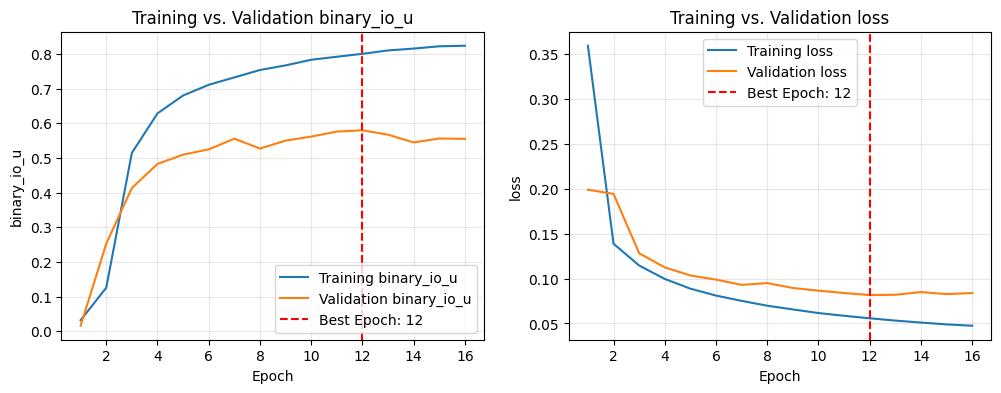

In [ ]:
plot_training_history(history, "binary_io_u", "loss")

## Evaluate model

31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - binary_io_u: 0.5552 - loss: 0.0853
Test IoU: 0.5552, Test Loss: 0.0853
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


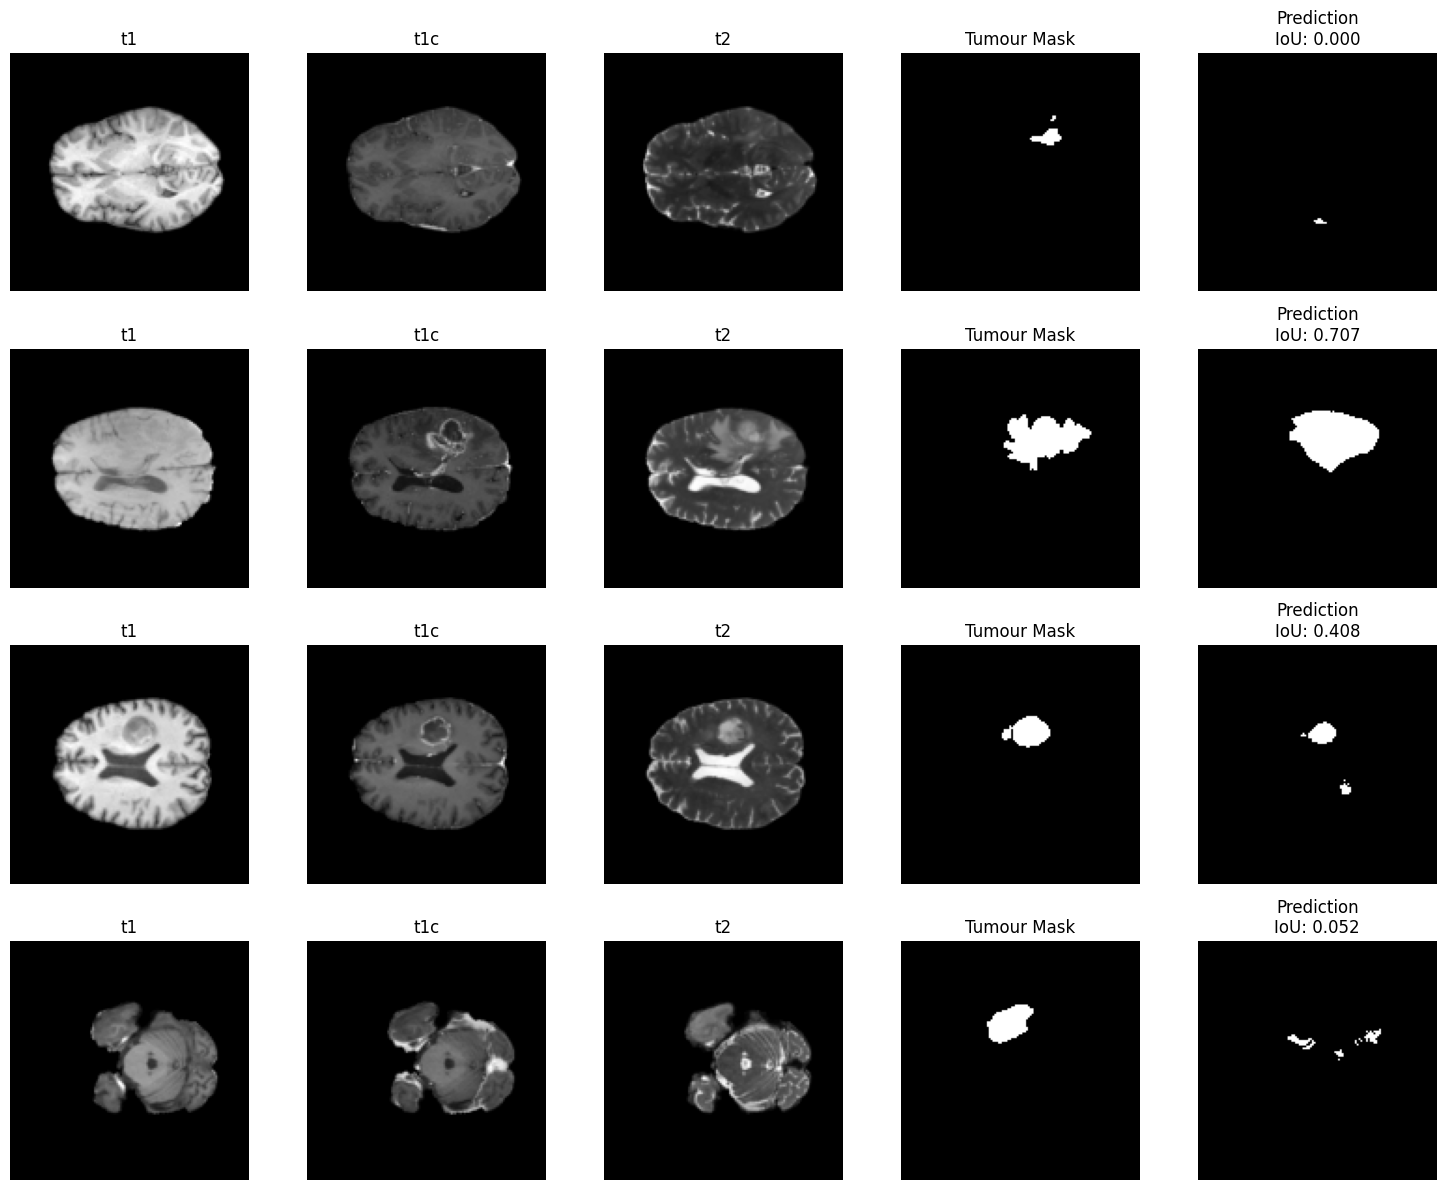

In [ ]:
loss, iou = model.evaluate(x_test, y_test)
print(f"Test IoU: {iou:.4f}, Test Loss: {loss:.4f}")
plot_binary_segmentation_prediction(x_test, y_test, model, 4)

## Notes

Plateaus around 66% IoU accuracy for validation on debug. 78% of full data